In [13]:
from collections import defaultdict
import re
sectors = [85, 86, 87]

cameras = [1, 2, 3, 4]
ccds = [1, 2, 3, 4]

import os

tic_to_location = {}


for sector in sectors:
    for camera in cameras:
        for ccd in ccds:
            base_dir = f'/pdo/qlp-data/sector-{sector}/ffi/cam{camera}/ccd{ccd}/REPORTS/'
            for filename in os.listdir(base_dir):
                pattern = re.compile(r"^(\d+)(?:-(\d+))?\.png$")
                match = pattern.match(filename)
                if match:
                    tic_id = int(match.group(1))              # always present
                    planet = int(match.group(2)) if match.group(2) else None
                    if not planet:
                        tic_to_location[f'{tic_id}01'] = base_dir + filename
                    else:
                        tic_to_location[f'{tic_id}0{planet}'] = base_dir + filename

print(len(tic_to_location))
    

11117


In [5]:
%matplotlib inline

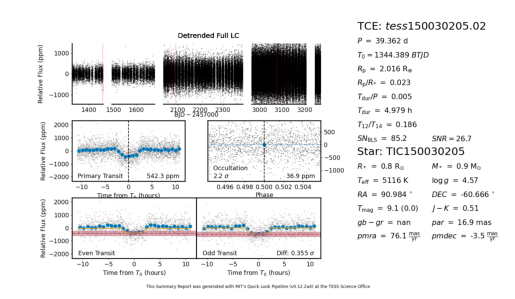

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

all_tics = [int(x) for x in list(tic_to_location.keys())]

path = tic_to_location['15003020502']#['14118607501']

img = mpimg.imread(path)
plt.imshow(img)
plt.axis("off")  # optional, hides axes
plt.show()


In [22]:
from qlp.lctools.lightcurve import QLPLightcurve
from lightcurvedb import db

with db:
    lc = QLPLightcurve.from_db(db, tic_id)

ModuleNotFoundError: No module named 'qlp.lctools'

Filename: /pdo/astronet-data//data/fits/sector-87/astronet_hlsp_qlp_tess_ffi-s0087-0000000141186075_tess_v01_llc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  LIGHTCURVE    1 BinTableHDU     26   157072R x 7C   [D, J, E, J, E, E, E]   
Columns:
1: TIME [BJD-2457000, days]
2: CADENCENO [None]
3: SAP_FLUX [None]
4: QUALITY [None]
5: SAP_FLUX_SML [None]
6: SAP_FLUX_MID [None]
7: SAP_FLUX_LAG [None]


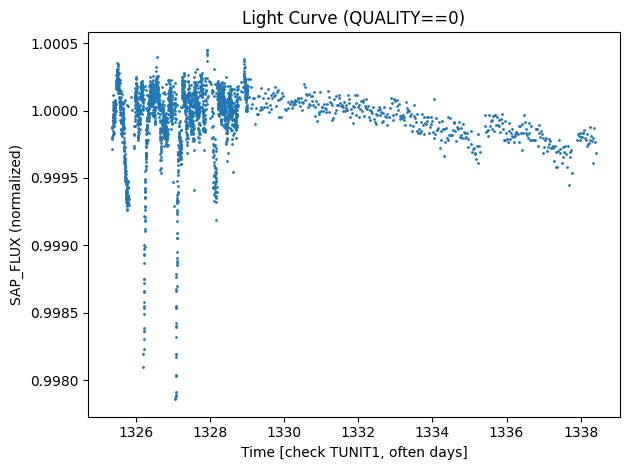

In [28]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt

fn = "/pdo/astronet-data//data/fits/sector-87/astronet_hlsp_qlp_tess_ffi-s0087-0000000141186075_tess_v01_llc.fits"
hdul = fits.open(fn)
hdul.info()

# Look at the columns in the first table HDU (often 1)
hdr = hdul[1].header
print("Columns:")
for i in range(1, 50):
    ttype = hdr.get(f"TTYPE{i}")
    tunit = hdr.get(f"TUNIT{i}")
    if ttype is None:
        break
    print(f"{i}: {ttype} [{tunit}]")

# Or view as an Astropy Table to see names and dtypes:
tab = Table(hdul[1].data)
tab

with fits.open(fn) as hdul:
    data = hdul[1].data  # table HDU

time = data["TIME"]
flux = data["SAP_FLUX"]
quality = data["QUALITY"]

# Keep finite values; QUALITY==0 is usually "good"
mask = np.isfinite(time) & np.isfinite(flux) & (quality == 0)
t = time[mask]
f = flux[mask]

t = t[:2500]
f = f[:2500]

# Normalize about the median for a nice y~1 plot
f_norm = f / np.nanmedian(f)

plt.figure()
plt.plot(t, f_norm, ".", ms=2)
plt.xlabel("Time [check TUNIT1, often days]")
plt.ylabel("SAP_FLUX (normalized)")
plt.title("Light Curve (QUALITY==0)")
plt.tight_layout()
plt.show()





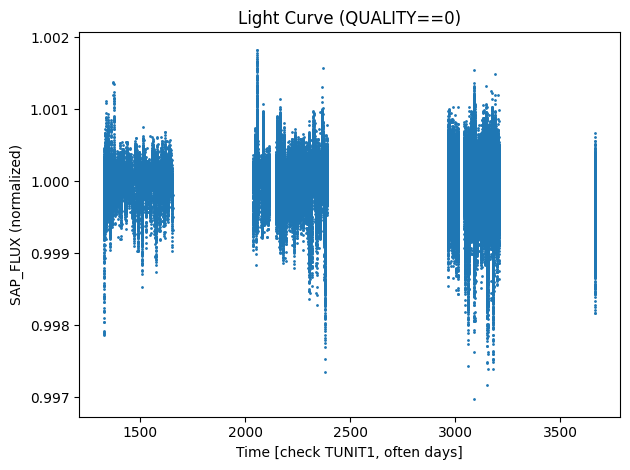

In [27]:
from light_curve_util import tess_io
import os

def custom_read_light_curve(filename, flux_key):
    f = fits.open(filename)
    time = (f[1].data["TIME"]).astype(float)
    flux = (f[1].data[flux_key]).astype(float)
    quality = f[1].data["QUALITY"]
    mask = np.isfinite(time) & np.isfinite(flux) & (quality == 0)
    time = time[mask]
    flux = flux[mask]
    return time, flux

def read_and_process_light_curve(tess_data_dir, flux_key, filename, min_t, max_t):
  filename = os.path.join(tess_data_dir, filename) 
  all_time, all_mag = custom_read_light_curve(filename, flux_key)
    
  mask = np.logical_and(all_time >= min_t, all_time <= max_t)
  all_time = all_time[mask]
  all_mag = all_mag[mask]

  assert len(all_time)
  return all_time, all_mag

tic = 141186075
fn = f"/pdo/astronet-data//data/fits/sector-87/astronet_hlsp_qlp_tess_ffi-s0087-0000000{tic}_tess_v01_llc.fits"
fn = f'astronet_hlsp_qlp_tess_ffi-s0087-0000000{tic}_tess_v01_llc.fits'

t, f = read_and_process_light_curve('/pdo/users/dimond/bad_tic_fits/', 'SAP_FLUX', fn, -np.inf, np.inf)
plt.figure()
plt.plot(t, f, ".", ms=2)
plt.xlabel("Time [check TUNIT1, often days]")
plt.ylabel("SAP_FLUX (normalized)")
plt.title("Light Curve (QUALITY==0)")
plt.tight_layout()
plt.show()